<div style="background:linear-gradient(135deg,#4c0519 0%,#be123c 55%,#fb7185 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 157 &middot; Communicating Results &middot; Challenge Solutions</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Practice Challenges &middot; Worked Solutions</div>
  <div style="font-size:15px;color:#ffe4e6;max-width:760px;line-height:1.6">Worked answers to the five practice challenges. Two are writing tasks, shown as example answers; three are worked in code. A human-authored solution document (report-solutions.docx), with the visuals and the headlines side by side, is downloadable from the chapter so you can check your work.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
mpl.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,
    "axes.titlelocation":"left","axes.titlepad":10})
ROSE, INK, MUT, GR, RD = "#be123c", "#1a2138", "#64748b", "#16a34a", "#dc2626"
try:
    import docx
except ModuleNotFoundError:                      # python-docx is not preinstalled on Google Colab
    import sys, subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "-q", "python-docx"]); import docx
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "communicating-insights--company-data.xlsx"
def load(sheet):
    try: return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
sales = load("SalesMonthly"); ab = load("ABTest")

## Challenge 1 &middot; Rewrite the lede (BLUF)
This is a writing task, so there is no single right answer, but a good one leads with the decision, not the method. Here is a before and after.

> **Before (buries the lede):** &#8220;We ran an ordinary least squares regression of satisfaction on four drivers, and the model achieved an R-squared of 0.84.&#8221;
>
> **After (BLUF, for an executive):** &#8220;Ease of use is the biggest lever on customer satisfaction, by a clear margin, so it is where we should invest first. Our analysis explains the large majority of what makes customers happy, and ease of use tops the list.&#8221;

The after states the recommendation first and keeps the statistic (R-squared) as supporting detail, not the headline.

## Challenge 2 &middot; Fix a misleading chart
The misleading chart put the A/B rates on a truncated axis. Redraw it with a zero baseline, and the takeaway changes from &#8216;B is enormous&#8217; to &#8216;B is a real but modest improvement&#8217;.

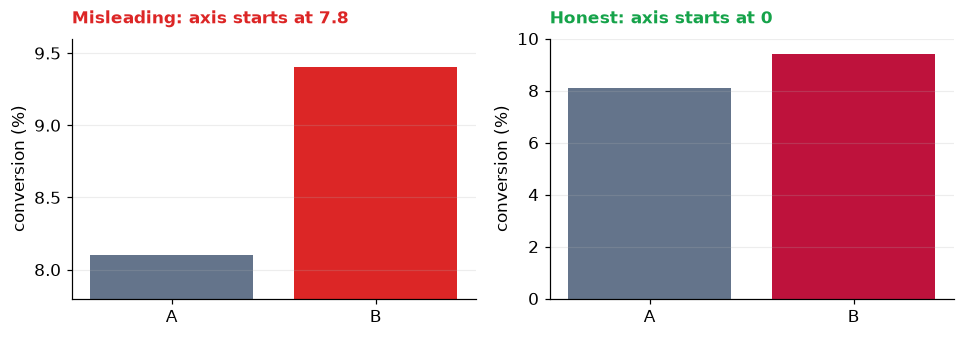

Takeaway change: the truncated axis makes B look several times bigger; the zero baseline reveals a genuine but modest 16% relative lift.


In [2]:
a, b = 8.1, 9.4
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].bar(["A","B"], [a, b], color=[MUT, RD]); ax[0].set_ylim(7.8, 9.6)
ax[0].set_title("Misleading: axis starts at 7.8", color=RD, fontsize=11)
ax[1].bar(["A","B"], [a, b], color=[MUT, ROSE]); ax[1].set_ylim(0, 10)
ax[1].set_title("Honest: axis starts at 0", color=GR, fontsize=11)
for a_ in ax: a_.set_ylabel("conversion (%)"); a_.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()
print("Takeaway change: the truncated axis makes B look several times bigger; the zero baseline reveals a genuine but modest 16% relative lift.")

## Challenge 3 &middot; Build a report-ready table, and export it to Word
Format the revenue-by-region figures for a reader, shade the largest value, add a total row, then drop the finished table into a Word document.

In [3]:
byregion = sales.groupby("region").revenue.sum().sort_values(ascending=False)
tbl = pd.DataFrame({"Region": byregion.index, "Revenue": byregion.values})
tbl["Share"] = tbl.Revenue / tbl.Revenue.sum()
total = pd.DataFrame({"Region": ["TOTAL"], "Revenue": [tbl.Revenue.sum()], "Share": [1.0]})
full = pd.concat([tbl, total], ignore_index=True)
styled = (full.style.hide(axis="index")
          .format({"Revenue": "${:,.0f}", "Share": "{:.1%}"})
          .background_gradient(subset=pd.IndexSlice[:len(tbl)-1, "Revenue"], cmap="Reds")
          .set_properties(subset=pd.IndexSlice[full.index[-1], :], **{"font-weight": "bold"}))
styled

Region,Revenue,Share
North,"$535,879",24.9%
West,"$489,393",22.7%
East,"$422,289",19.6%
South,"$379,930",17.6%
Central,"$327,447",15.2%
TOTAL,"$2,154,938",100.0%


In [4]:
# the mechanical skill the challenge asks for: drop the finished table into a Word document
from docx import Document
import tempfile, os
disp = full.assign(Revenue=full.Revenue.map("${:,.0f}".format), Share=full.Share.map("{:.1%}".format))
wd = Document(); wd.add_heading("Revenue by Region", level=1)
t = wd.add_table(rows=1, cols=len(disp.columns)); t.style = "Light Grid Accent 1"
for j, col in enumerate(disp.columns):
    t.rows[0].cells[j].text = col; t.rows[0].cells[j].paragraphs[0].runs[0].bold = True
for _, r in disp.iterrows():
    cs = t.add_row().cells
    for j, col in enumerate(disp.columns): cs[j].text = str(r[col])
demo = os.path.join(tempfile.mkdtemp(), "region_table.docx"); wd.save(demo)
print(disp.to_string(index=False)); print("\nexported a Word copy to", demo)

 Region    Revenue  Share
  North   $535,879  24.9%
   West   $489,393  22.7%
   East   $422,289  19.6%
  South   $379,930  17.6%
Central   $327,447  15.2%
  TOTAL $2,154,938 100.0%

exported a Word copy to /var/folders/wv/rntn6xtd407cmdsyx0b0wwnw0000gn/T/tmpegpi0xfb/region_table.docx


## Challenge 4 &middot; Adapt the analysis, and rewrite the lede
Rank the regions by number of orders instead of revenue, then write the one-sentence bottom line. Ranking by orders can tell a different story than ranking by revenue, since a region can have many small orders or few large ones.

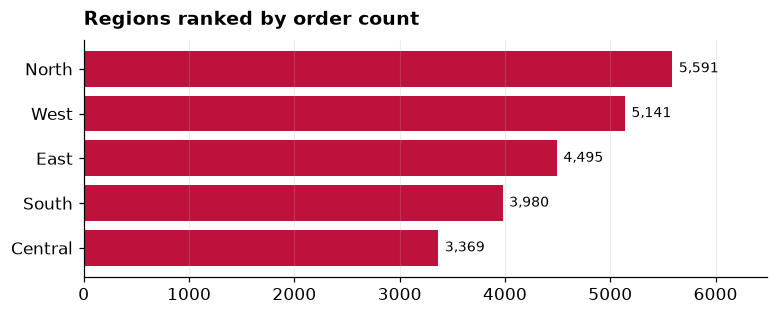

top region by orders: North (5,591) | top region by revenue: North
Example bottom line: "North leads not just in revenue but in sheer order volume, so it is our busiest market as well as our biggest, and the natural place to protect first."


In [5]:
by_orders = sales.groupby("region").orders.sum().sort_values()
fig_orders, ax = plt.subplots(figsize=(7.2, 3.0))
ax.barh(by_orders.index, by_orders.values, color=ROSE)
for y, v in enumerate(by_orders.values): ax.text(v+60, y, f"{v:,}", va="center", fontsize=9)
ax.set_title("Regions ranked by order count"); ax.set_xlim(0, by_orders.max()*1.16); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()
top_o = by_orders.idxmax(); top_r = sales.groupby("region").revenue.sum().idxmax()
print(f"top region by orders: {top_o} ({by_orders.max():,}) | top region by revenue: {top_r}")
print("Example bottom line: \"North leads not just in revenue but in sheer order volume, so it is our busiest market as well as our biggest, and the natural place to protect first.\"")

## Challenge 5 &middot; Translate the metric for two audiences
The same A/B result, told for two readers. Each gets the number that maps to their decision.

> **For the Growth team (they care about the rate and the lift):** &#8220;The new checkout converts 16 percent better than the current one, 9.4 percent against 8.1 percent, and the result is statistically significant.&#8221;
>
> **For the CFO (they care about the money):** &#8220;Rolling out the new checkout should convert about 1.3 more buyers per 100 visitors. On our current traffic that is a meaningful revenue gain for a one-time design change, with little downside.&#8221;

Same finding, two framings: the rate and significance for the team that optimizes it, the dollar impact for the person who funds it.

### Wrap-up
Two writing tasks and three worked in code: lead with the answer, redraw the honest chart, format and export a table, rank by a different metric and restate the finding, and translate one result for two audiences. The finished **solution document** (report-solutions.docx, downloadable from the chapter) is a human-authored write-up that lays out all five answers, the visuals beside the headlines, so you can compare your work. The writing answers are examples, so yours will differ in wording but should share the same instinct, say the finding first, and say it plainly.